# 🏨 Patel Delivers Hotel Group — Operational Performance Analysis

**Author:** Harshil Patel  
**Domain:** Hospitality Analytics  
**Tools:** Python (Pandas, Matplotlib, Seaborn)  
**Dataset Period:** May 2022 — August 2022  

---

## Business Context

Patel Delivers Hotel Group is a luxury and business hotel chain operating across 
four major Indian cities — Delhi, Mumbai, Bangalore, and Hyderabad — with over 
20 years of market presence. The group manages multiple properties including 
Atliq Grands, Atliq Exotica, Atliq Bay, Atliq Palace, Atliq Blu, Atliq City, 
and Atliq Seasons, offering four room categories: Standard, Elite, Premium, 
and Presidential.

Guests book rooms through multiple channels — the brand's direct website, 
and third-party platforms including MakeYourTrip, LogTrip, Tripster, and 
offline agents.

---

## Business Problem

The hotel group is experiencing a **decline in revenue and market share** 
driven by increasing competition. Senior management has commissioned a 
data-driven operational audit to answer three core questions:

1. **Where** is the business underperforming — which cities, properties, 
   and room types?
2. **When** does performance drop — are weekdays, weekends, or specific 
   months the problem?
3. **Why** — is it occupancy, pricing, booking channel mix, or 
   customer satisfaction?

---

## Analytical Approach

This analysis covers four performance dimensions:

| Dimension | Key Metric |
|---|---|
| Occupancy | Occupancy Rate (%) |
| Revenue | Revenue Realised (₹) |
| Booking Channels | Platform share & cancellation behaviour |
| Customer Satisfaction | Average ratings by city and property |

The goal is not just to describe the data — but to deliver **actionable 
recommendations** that management can act on immediately.

## 📂 Dataset Overview

This analysis uses **6 datasets** sourced from the hotel group's booking 
and operations database.

---

### Dimension Tables (Reference Data)

| File | Rows | Columns | Description |
|---|---|---|---|
| `dim_hotels.csv` | 25 | 4 | Property details — name, category (Luxury/Business), city |
| `dim_rooms.csv` | 4 | 2 | Room type mapping — RT1 to RT4 and their class names |
| `dim_date.csv` | 92 | 4 | Calendar reference — date, month, week number, day type |

---

### Fact Tables (Transactional Data)

| File | Rows | Columns | Description |
|---|---|---|---|
| `fact_bookings.csv` | 134,590 | 12 | Individual booking records — revenue, platform, ratings, status |
| `fact_aggregated_bookings.csv` | 9,200 | 5 | Daily room-level bookings vs capacity per property |
| `new_data_august.csv` | 7 | 13 | August 2022 update — appended during analysis |

---

### Data Model — How the Tables Connect

- `fact_bookings` → joins to `dim_hotels` on `property_id`
- `fact_bookings` → joins to `dim_date` on `check_in_date`
- `fact_aggregated_bookings` → joins to `dim_rooms` on `room_category`
- `fact_aggregated_bookings` → joins to `dim_hotels` on `property_id`

---

### Key Business Metrics Derived in This Analysis

| Metric | Formula | Business Meaning |
|---|---|---|
| **Occupancy Rate** | successful_bookings / capacity × 100 | How full are the hotels? |
| **Revenue Realised** | Actual revenue after cancellations | What did the hotel actually earn? |
| **RevPAR** | Revenue Realised / Total Capacity | Revenue per available room |
| **Cancellation Rate** | Cancelled bookings / Total bookings | How much revenue is being lost? |

In [67]:
# =============================================================================
# SECTION 1: DATA IMPORT & VALIDATION
# =============================================================================

# --- Libraries ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display Settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# --- Load All Datasets --- 
df_bookings      = pd.read_csv('datasets/fact_bookings.csv')
df_agg_bookings  = pd.read_csv('datasets/fact_aggregated_bookings.csv')
df_hotels        = pd.read_csv('datasets/dim_hotels.csv')
df_rooms         = pd.read_csv('datasets/dim_rooms.csv')
df_date          = pd.read_csv('datasets/dim_date.csv')


# --- Confirm All Files Loaded Successfully ---
datasets = {
    'fact_bookings'           : df_bookings,
    'fact_aggregated_bookings': df_agg_bookings,
    'dim_hotels'              : df_hotels,
    'dim_rooms'               : df_rooms,
    'dim_date'                : df_date
}

print("All datasets loaded successfully\n")
print(f"{'Dataset':<30} {'Rows':>8} {'Columns':>10}")
print("-" * 50)
for name, df in datasets.items():
    print(f"{name:<30} {df.shape[0]:>8} {df.shape[1]:>10}")

All datasets loaded successfully

Dataset                            Rows    Columns
--------------------------------------------------
fact_bookings                    134590         12
fact_aggregated_bookings           9200          5
dim_hotels                           25          4
dim_rooms                             4          2
dim_date                             92          4


## 🔍 Section 1.1 — Data Validation

Before any analysis, we validate each dataset by checking:

- **Shape** — how many rows and columns?
- **Sample rows** — does the data look as expected?
- **Data types** — are dates stored as dates, numbers as numbers?
- **Null values** — which columns have missing data?

This step ensures we understand the quality of our data
before drawing any conclusions from it.

In [68]:
# =============================================================================
# QUICK VALIDATION — Shape, Sample & Null Check Across All Datasets
# =============================================================================

for name, df in datasets.items():
    print("=" * 60)
    print(f"📋 {name}")
    print(f"   Shape : {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\n   First 3 rows:")
    print(df.head(3).to_string())
    print(f"\n   Data Types:")
    print(df.dtypes.to_string())
    print(f"\n   Null Values:")
    print(df.isnull().sum().to_string())
    print()

📋 fact_bookings
   Shape : 134590 rows × 12 columns

   First 3 rows:
         booking_id  property_id booking_date check_in_date checkout_date  no_guests room_category booking_platform  ratings_given booking_status  revenue_generated  revenue_realized
0  May012216558RT11        16558     27-04-22      1/5/2022      2/5/2022      -3.00           RT1    direct online           1.00    Checked Out              10010             10010
1  May012216558RT12        16558     30-04-22      1/5/2022      2/5/2022       2.00           RT1           others            NaN      Cancelled               9100              3640
2  May012216558RT13        16558     28-04-22      1/5/2022      4/5/2022       2.00           RT1          logtrip           5.00    Checked Out            9100000              9100

   Data Types:
booking_id            object
property_id            int64
booking_date          object
check_in_date         object
checkout_date         object
no_guests            float64
room_cat

## 🧹 Section 2 — Data Cleaning

Raw data is never perfect. Before drawing any conclusions,
I must identify and fix data quality issues that could
lead to incorrect business insights.

Based on our validation in Section 1, I identified

**4 data quality issues** to address:

| # | Issue | Column | Action |
|---|---|---|---|
| 1 | Negative guest count | `no_guests` | Remove rows where no_guests <= 0 |
| 2 | Revenue outliers | `revenue_generated` | Remove using Mean ± 3×Std method |
| 3 | Missing ratings | `ratings_given` | Keep as-is — 58% missing, not an error |
| 4 | Dates stored as text | `booking_date`, `check_in_date`, `checkout_date` | Convert to datetime format |

---

> **Why this matters:** Dirty data leads to wrong insights.
> Wrong insights lead to wrong business decisions.
> A good analyst fixes the data before trusting it.

### 🔧 Fix 1 — Remove Invalid Guest Counts

**Problem:** Some bookings have `no_guests <= 0` which is
physically impossible. These are data entry errors.

**Action:** Remove all rows where the guest count is zero or negative.

In [69]:
# Check invalid guest entries before cleaning
print(f"Rows with invalid guest count : {(df_bookings.no_guests <= 0).sum()}")
print(f"Total rows before cleaning    : {df_bookings.shape[0]}")

# Remove invalid guests
df_bookings = df_bookings[df_bookings.no_guests > 0]

print(f"\nTotal rows after cleaning     : {df_bookings.shape[0]}")
print(f"Rows removed                  : {134590 - df_bookings.shape[0]}")

Rows with invalid guest count : 9
Total rows before cleaning    : 134590

Total rows after cleaning     : 134578
Rows removed                  : 12


### 🔧 Fix 2 — Remove Revenue Outliers

**Problem:** Some bookings show extremely high `revenue_generated`
values — for example ₹9,100,000 — while the typical booking
ranges between ₹8,000 and ₹15,000. These are clear data errors.

**Action:** Use the **Mean ± 3×Standard Deviation** method to
identify and remove statistical outliers.

**Why Mean ± 3×Std?**
In a normal distribution, 99.7% of values fall within
3 standard deviations of the mean. Anything beyond that
is statistically abnormal and likely a data error.

In [70]:
# Step 1 — Check current revenue range
print(f"Min revenue  : {df_bookings.revenue_generated.min()}")
print(f"Max revenue  : {df_bookings.revenue_generated.max()}")
print(f"Mean revenue : {df_bookings.revenue_generated.mean():.2f}")
print(f"Std revenue  : {df_bookings.revenue_generated.std():.2f}")

# Step 2 — Calculate outlier boundaries
mean = df_bookings.revenue_generated.mean()
std  = df_bookings.revenue_generated.std()

upper_limit = mean + 3 * std
lower_limit = mean - 3 * std

print(f"\nUpper limit  : {upper_limit:.2f}")
print(f"Lower limit  : {lower_limit:.2f}")

# Step 3 — Check how many outliers exist
outliers = df_bookings[df_bookings.revenue_generated > upper_limit]
print(f"\nOutlier rows found : {outliers.shape[0]}")

# Step 4 — Remove outliers
df_bookings = df_bookings[df_bookings.revenue_generated <= upper_limit]
print(f"Rows after cleaning: {df_bookings.shape[0]}")

Min revenue  : 6500
Max revenue  : 28560000
Mean revenue : 15378.04
Std revenue  : 93040.15

Upper limit  : 294498.50
Lower limit  : -263742.43

Outlier rows found : 5
Rows after cleaning: 134573


### 🔧 Fix 3 — Handle Missing Ratings

**Problem:** `ratings_given` has 77,907 null values out of
134,590 rows — meaning **58% of bookings have no rating.**

**Action:** We do NOT remove or fill these values.

**Why?**
- Removing them would delete 58% of our booking data
- Filling with mean or median would create **fake ratings**
  that distorts customer satisfaction analysis
- The nulls simply mean the guest chose not to rate —
  That is valid real-world behaviour

**How we handle it:** We use `.dropna()` only when
Specifically analysing ratings — for all other analysis
The full dataset remains intact.

In [84]:
# Confirm null rating count
total_rows    = df_bookings.shape[0]
null_ratings  = df_bookings.ratings_given.isnull().sum()
rated_bookings = total_rows - null_ratings

print(f"Total bookings         : {total_rows}")
print(f"Bookings with ratings  : {rated_bookings}")
print(f"Bookings without rating: {null_ratings}")
print(f"Rating coverage        : {(rated_bookings/total_rows*100):.2f}%")

# No rows removed — we acknowledge and move on
print("\n✔ No action taken — null ratings retained intentionally")

Total bookings         : 134573
Bookings with ratings  : 56676
Bookings without rating: 77897
Rating coverage        : 42.12%

✔ No action taken — null ratings retained intentionally


### 🔧 Fix 4 — Convert Date Columns to Datetime Format

**Problem:** Three date columns are stored as `object` (text):
- `booking_date`
- `check_in_date`
- `checkout_date`

**Action:** Convert all three to proper `datetime` format.

**Why does this matter?**
As long as dates are stored as text, Python cannot:
- Sort bookings chronologically
- Calculate length of stay (checkout - check_in)
- Filter by month or week
- Plot time-based trends

Converting to datetime **unlocks time-series analysis.**

In [71]:
# Before conversion — confirm current data types
print("Before conversion:")
print(df_bookings[['booking_date','check_in_date','checkout_date']].dtypes)

# Convert with mixed format handling
df_bookings['booking_date']  = pd.to_datetime(df_bookings['booking_date'], format='mixed', dayfirst=True)
df_bookings['check_in_date'] = pd.to_datetime(df_bookings['check_in_date'], format='mixed', dayfirst=True)
df_bookings['checkout_date'] = pd.to_datetime(df_bookings['checkout_date'], format='mixed', dayfirst=True)

# After conversion — confirm new data types
print("\nAfter conversion:")
print(df_bookings[['booking_date','check_in_date','checkout_date']].dtypes)

# Calculate length of stay
df_bookings['length_of_stay'] = (
    df_bookings['checkout_date'] - df_bookings['check_in_date']
).dt.days

print(f"\nAverage length of stay : {df_bookings['length_of_stay'].mean():.2f} days")
print(f"Min length of stay     : {df_bookings['length_of_stay'].min()} days")
print(f"Max length of stay     : {df_bookings['length_of_stay'].max()} days")

Before conversion:
booking_date     object
check_in_date    object
checkout_date    object
dtype: object

After conversion:
booking_date     datetime64[ns]
check_in_date    datetime64[ns]
checkout_date    datetime64[ns]
dtype: object

Average length of stay : 2.37 days
Min length of stay     : 1 days
Max length of stay     : 6 days


In [ ]:
# =============================================================================
# DATA CLEANING SUMMARY
# =============================================================================

print("=" * 50)
print("       DATA CLEANING SUMMARY")
print("=" * 50)
print(f"Fix 1 — Invalid guests removed   : done")
print(f"Fix 2 — Revenue outliers removed  : done")
print(f"Fix 3 — Null ratings retained     : done")
print(f"Fix 4 — Date columns converted    : done")
print(f"Fix 4 — Length of stay created    : done")
print("=" * 50)
print(f"Final dataset shape : {df_bookings.shape[0]} rows × {df_bookings.shape[1]} columns")

## ⚙️ Section 3 — Data Transformation

Cleaned data is not always analysis-ready. In this section
we **engineer new columns** that unlock deeper business insights.

We will create three new columns:

| New Column | Formula | Business Meaning |
|---|---|---|
| `occ_pct` | successful_bookings / capacity × 100 | How full is each property per day? |
| `RevPAR` | revenue_realized / capacity | Revenue earned per available room |
| `cancellation_rate` | cancelled / total bookings × 100 | How much revenue is being lost? |

---

> **Why feature engineering matters:** Raw columns tell you
> what happened. Derived columns tell you **how well** the
> business is performing. This is where analysis gets powerful.

In [73]:
# =============================================================================
# TRANSFORMATION 1 — Occupancy Percentage
# =============================================================================

# Fill null capacity values with median — fixed syntax
df_agg_bookings = df_agg_bookings.assign(
    capacity=df_agg_bookings['capacity'].fillna(df_agg_bookings['capacity'].median())
)

# Remove rows where bookings exceed capacity — data error
df_agg_bookings = df_agg_bookings[
    df_agg_bookings['successful_bookings'] <= df_agg_bookings['capacity']
].copy()

# Calculate occupancy percentage
df_agg_bookings['occ_pct'] = (
    df_agg_bookings['successful_bookings'] / df_agg_bookings['capacity'] * 100
).round(2)

print("Occupancy percentage column created successfully")
print(df_agg_bookings[['property_id','room_category',
                        'successful_bookings','capacity','occ_pct']].head(5))

Occupancy percentage column created successfully
   property_id room_category  successful_bookings  capacity  occ_pct
0        16559           RT1                   25     30.00    83.33
1        19562           RT1                   28     30.00    93.33
2        19563           RT1                   23     30.00    76.67
4        16558           RT1                   18     19.00    94.74
5        17560           RT1                   28     40.00    70.00


### ⚙️ Transformation 2 — RevPAR (Revenue Per Available Room)

**What is RevPAR?**
RevPAR is the most important revenue metric in the hotel industry.
It measures how much revenue a hotel earns per available room
— regardless of whether the room was booked or not.

**Formula:**
> RevPAR = Revenue Realised / Total Available Rooms (Capacity)

**Why RevPAR over total revenue?**

| Metric | Problem |
|---|---|
| Total Revenue | A bigger hotel always wins — unfair comparison |
| Occupancy % | High occupancy at low price looks good but earns little |
| **RevPAR** | Balances both — rewards high occupancy AND high price |

RevPAR is how hotel managers **compare performance fairly**
across properties of different sizes.

In [74]:
# =============================================================================
# TRANSFORMATION 2 — RevPAR (Revenue Per Available Room)
# =============================================================================

# Fix — convert check_in_date in agg_bookings to datetime first
df_agg_bookings['check_in_date'] = pd.to_datetime(
    df_agg_bookings['check_in_date'], format='mixed', dayfirst=True
)

# Merge bookings with hotels to get city and property name
df_revpar = pd.merge(df_bookings, df_hotels, on='property_id')

# Merge with aggregated bookings to get capacity
df_revpar = pd.merge(
    df_revpar,
    df_agg_bookings[['property_id', 'check_in_date', 'room_category', 'capacity']],
    on=['property_id', 'check_in_date', 'room_category'],
    how='left'
)

# Calculate RevPAR
df_revpar['RevPAR'] = (
    df_revpar['revenue_realized'] / df_revpar['capacity']
).round(2)

print("RevPAR column created successfully")
print(df_revpar[['property_name', 'city', 'room_category',
                  'revenue_realized', 'capacity', 'RevPAR']].head(5))

RevPAR column created successfully
  property_name   city room_category  revenue_realized  capacity  RevPAR
0  Atliq Grands  Delhi           RT1              3640     19.00  191.58
1  Atliq Grands  Delhi           RT1             10920     19.00  574.74
2  Atliq Grands  Delhi           RT1              9100     19.00  478.95
3  Atliq Grands  Delhi           RT1              3640     19.00  191.58
4  Atliq Grands  Delhi           RT1              9100     19.00  478.95


### ⚙️ Transformation 3 — Cancellation Rate

**What is Cancellation Rate?**
The percentage of total bookings that were cancelled
before the guest checked in.

**Formula:**
> Cancellation Rate = Cancelled Bookings / Total Bookings × 100

**Why does this matter?**
A cancelled booking means:
- The room may have gone unsold last minute
- Revenue was either lost or heavily discounted
- It directly impacts both RevPAR and total revenue

High cancellation rates on specific platforms or cities
point to a **specific business problem** — not a general one. 

In [75]:
# =============================================================================
# TRANSFORMATION 3 — Cancellation Rate
# =============================================================================

# Check unique booking statuses first
print("Booking status categories:")
print(df_bookings['booking_status'].unique())
print()

# Total bookings per property
total_bookings = df_bookings.groupby('property_id')['booking_id'].count()

# Cancelled bookings per property
cancelled_bookings = df_bookings[
    df_bookings['booking_status'] == 'Cancelled'
].groupby('property_id')['booking_id'].count()

# Calculate cancellation rate
df_cancellation = pd.DataFrame({
    'total_bookings'    : total_bookings,
    'cancelled_bookings': cancelled_bookings
}).fillna(0)

df_cancellation['cancellation_rate'] = (
    df_cancellation['cancelled_bookings'] /
    df_cancellation['total_bookings'] * 100
).round(2)

print("Cancellation rate per property:")
print(df_cancellation.sort_values('cancellation_rate', ascending=False))

Booking status categories:
['Cancelled' 'Checked Out' 'No Show']

Cancellation rate per property:
             total_bookings  cancelled_bookings  cancellation_rate
property_id                                                       
19560                  5978                1577              26.38
18563                  4728                1227              25.95
17558                  5036                1292              25.66
16561                  4418                1127              25.51
17562                  3424                 871              25.44
19563                  5413                1372              25.35
16562                  4818                1218              25.28
16563                  7147                1805              25.26
16558                  3147                 789              25.07
17560                  6013                1507              25.06
18558                  4475                1118              24.98
17564                  3981    

## 📊 Section 4 — Insights Generation

This section answers the three core business questions
defined at the start of this project:

1. **Where** is the business underperforming?
2. **When** does performance drop?
3. **Why** — occupancy, revenue, channels or ratings?

---

### Insights Covered

| # | Business Question | Dimension |
|---|---|---|
| 1 | Which room category has highest occupancy? | Occupancy |
| 2 | Which city has highest occupancy? | Occupancy |
| 3 | Weekday vs Weekend — when is occupancy better? | Occupancy |
| 4 | Which city generates the most revenue? | Revenue |
| 5 | Which property generates the most revenue? | Revenue |
| 6 | How does revenue trend month by month? | Revenue |
| 7 | Which booking platform drives most cancellations? | Channels |
| 8 | Which city has the best customer ratings? | Satisfaction |

---

> **Analytical approach:** Every insight follows the same
> structure — business question first, code second,
> observation third. Data without interpretation
> is just numbers.

### 📊 Insight 1 — Occupancy Rate by Room Category

**Business Question:**
Which room category is most in demand across all properties?

**Why this matters:**
If one room type consistently shows higher occupancy,
the hotel group should consider expanding that category
or adjusting pricing upward to maximise revenue.

Average Occupancy % by Room Category:
room_class
Presidential   59.28
Premium        58.03
Elite          58.01
Standard       57.89
Name: occ_pct, dtype: float64


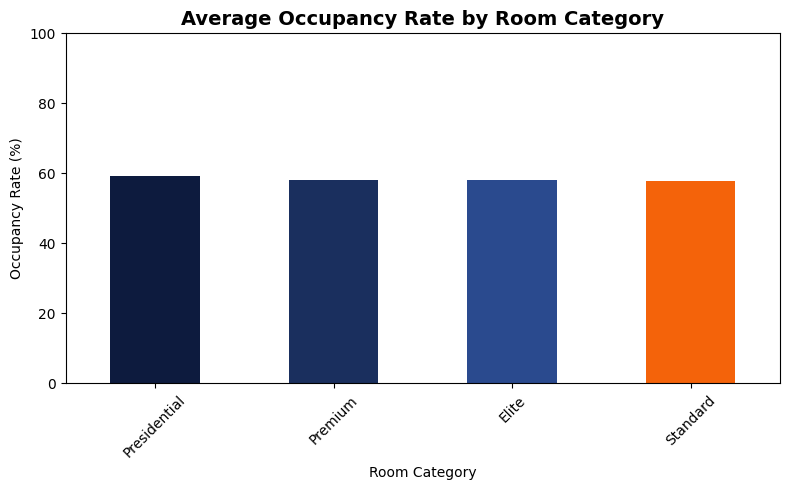

In [98]:
# =============================================================================
# INSIGHT 1 — Occupancy Rate by Room Category
# =============================================================================

# Merge agg_bookings with rooms to get room class names
df_occ_room = pd.merge(
    df_agg_bookings, df_rooms,
    left_on='room_category', right_on='room_id'
)

# Calculate average occupancy per room class
occ_by_room = df_occ_room.groupby('room_class')['occ_pct'].mean().round(2).sort_values(ascending=False)
print("Average Occupancy % by Room Category:")
print(occ_by_room)

# Plot
plt.figure(figsize=(8, 5))
occ_by_room.plot(kind='bar', color=['#0D1B3E','#1a2f5e','#2a4a8e','#F4630A'])
plt.title('Average Occupancy Rate by Room Category', fontsize=14, fontweight='bold')
plt.xlabel('Room Category')
plt.ylabel('Occupancy Rate (%)')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('visuals/occupancy_by_room_category.png', dpi=150, bbox_inches='tight')
plt.show()


#### 🔍 Observation — Insight 1

Average occupancy across all room categories sits between
**57% and 59%** — remarkably consistent with no single
category significantly outperforming others.

**Business Implication:**
This flat occupancy distribution suggests demand is not
the differentiating factor between room types. The
underperformance at ~58% — below the industry benchmark
of 65–70% — points to a **systemic issue** affecting
all room categories equally, likely pricing strategy
or booking channel inefficiency.

### 📊 Insight 2 — Occupancy Rate by City

**Business Question:**
Which city has the highest and lowest occupancy rate
across all properties?

**Why this matters:**
Cities with low occupancy may need targeted marketing
campaigns, pricing adjustments, or capacity reduction.
Cities with high occupancy present an opportunity to
increase room rates without losing demand.

Average Occupancy % by City:
city
Delhi       61.51
Hyderabad   58.12
Mumbai      57.91
Bangalore   56.33
Name: occ_pct, dtype: float64


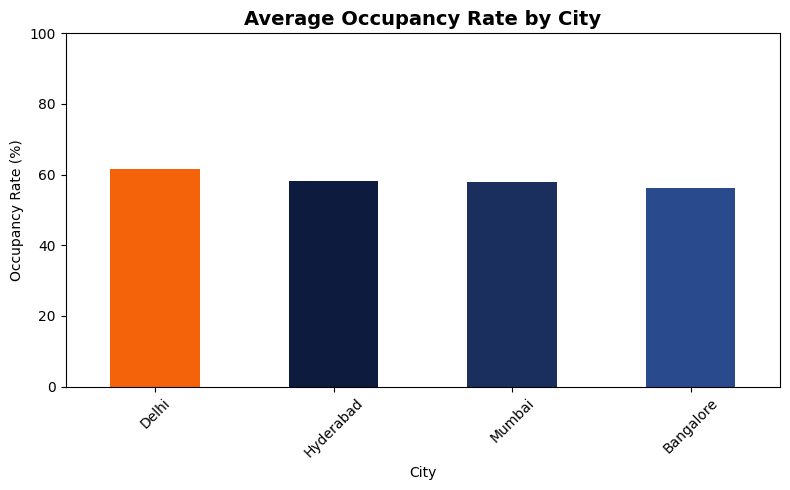

In [99]:
# =============================================================================
# INSIGHT 2 — Occupancy Rate by City
# =============================================================================

# Merge agg_bookings with hotels to get city names
df_occ_city = pd.merge(df_agg_bookings, df_hotels, on='property_id')

# Calculate average occupancy per city
occ_by_city = df_occ_city.groupby('city')['occ_pct'].mean().round(2).sort_values(ascending=False)
print("Average Occupancy % by City:")
print(occ_by_city)

# Plot
plt.figure(figsize=(8, 5))
occ_by_city.plot(kind='bar', color=['#F4630A','#0D1B3E','#1a2f5e','#2a4a8e'])
plt.title('Average Occupancy Rate by City', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Occupancy Rate (%)')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('visuals/avg_occupancy_rate_city.png', dpi=150, bbox_inches='tight')
plt.show()


#### 🔍 Observation — Insight 2

**Results:**
| City | Avg Occupancy % |
|---|---|
| Delhi | 61.51% |
| Hyderabad | 58.12% |
| Mumbai | 57.91% |
| Bangalore | 56.33% |

**Business Implication:**

Delhi leads occupancy at 61.51% — the only city
approaching industry benchmark of 65–70%.

Bangalore sits at the bottom with 56.33% — nearly
5 percentage points below Delhi. For a hotel group
operating 20+ years, this gap signals a **market
positioning problem** in Bangalore, not just a
demand problem.

**Recommendation:**
- Delhi → consider gradual room rate increases
  to capitalise on stronger demand
- Bangalore → investigate competitor pricing and
  review booking channel mix to diagnose
  the underperformance

### 📊 Insight 3 — Weekday vs Weekend Occupancy

**Business Question:**
Does occupancy perform better on weekdays or weekends
across all properties?

**Why this matters:**
If weekends consistently outperform weekdays, the hotel
group should introduce **weekday promotions** to drive
demand during slow periods. If weekdays are stronger,
the business likely serves corporate travellers —
which requires a completely different marketing strategy.

Average Occupancy % by Day Type:
day_type
weekend    73.96
weekeday   51.81
Name: occ_pct, dtype: float64


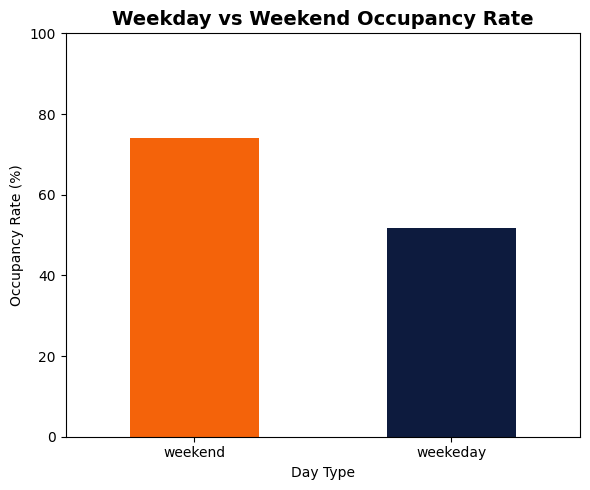

In [100]:
# =============================================================================
# INSIGHT 3 — Weekday vs Weekend Occupancy
# =============================================================================

# Fix — convert date column in df_date to datetime
df_date['date'] = pd.to_datetime(df_date['date'], format='mixed', dayfirst=True)

# Merge agg_bookings with date table
df_occ_day = pd.merge(
    df_agg_bookings, df_date,
    left_on='check_in_date', right_on='date'
)

# Calculate average occupancy by day type
occ_by_daytype = df_occ_day.groupby('day_type')['occ_pct'].mean().round(2).sort_values(ascending=False)
print("Average Occupancy % by Day Type:")
print(occ_by_daytype)

# Plot
plt.figure(figsize=(6, 5))
occ_by_daytype.plot(kind='bar', color=['#F4630A','#0D1B3E'])
plt.title('Weekday vs Weekend Occupancy Rate', fontsize=14, fontweight='bold')
plt.xlabel('Day Type')
plt.ylabel('Occupancy Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('visuals/weekdays_vs_weekend.png', dpi=150, bbox_inches='tight')
plt.show()


#### 🔍 Observation — Insight 3

**Results:**
| Day Type | Avg Occupancy % |
|---|---|
| Weekend | 73.96% |
| Weekday | 51.81% |

**Gap: 22 percentage points**

**Business Implication:**

Weekend occupancy at 73.96% is healthy and approaches
industry benchmark. However weekday occupancy at 51.81%
is critically low — meaning hotels are sitting more than
**half empty on weekdays.**

This pattern strongly suggests Patel Delivers properties
are attracting **leisure travellers** rather than corporate
travellers. Corporate guests typically book on weekdays
and represent a highly profitable, repeat customer segment.

**Recommendation:**
- Launch **weekday corporate packages** targeting
  business travellers in Delhi, Mumbai and Hyderabad
- Introduce **weekday dynamic pricing** — lower rates
  Monday to Thursday to stimulate demand
- Partner with local businesses and event organisers
  for corporate room block bookings
- Investigate why Bangalore specifically struggles —
  it had the lowest overall occupancy and likely
  the weakest weekday performance

### 📊 Insight 4 — Revenue Realised by City

**Business Question:**
Which city generates the most revenue for
Patel Delivers Hotel Group?

**Why this matters:**
Occupancy tells us how full the hotels are.
Revenue tells us how much money they actually made.
A city can have high occupancy but low revenue
if room rates are too low — or vice versa.
This insight connects occupancy performance
to actual financial output.

Total Revenue Realised by City:
city
Mumbai       668569251
Bangalore    420383550
Hyderabad    325179310
Delhi        294404488
Name: revenue_realized, dtype: int64


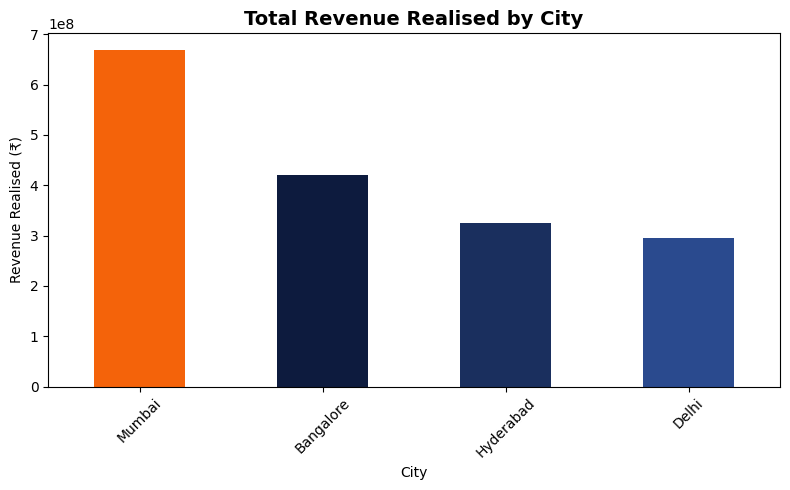

In [106]:
# =============================================================================
# INSIGHT 4 — Revenue Realised by City
# =============================================================================

# Merge bookings with hotels to get city
df_rev_city = pd.merge(df_bookings, df_hotels, on='property_id')

# Total revenue realised per city
rev_by_city = df_rev_city.groupby('city')['revenue_realized'].sum().sort_values(ascending=False)
print("Total Revenue Realised by City:")
print(rev_by_city)

# Plot
plt.figure(figsize=(8, 5))
rev_by_city.plot(kind='bar', color=['#F4630A','#0D1B3E','#1a2f5e','#2a4a8e'])
plt.title('Total Revenue Realised by City', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Revenue Realised (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visuals/revenue_by_city.png', dpi=150, bbox_inches='tight')
plt.show()


#### 🔍 Observation — Insight 4

**Results:**
| City | Revenue Realised |
|---|---|
| Mumbai | ₹668,569,251 |
| Bangalore | ₹420,383,550 |
| Hyderabad | ₹325,179,310 |
| Delhi | ₹294,404,488 |

**The Surprising Finding:**

Cross-referencing with Insight 2 reveals a critical paradox:

| City | Occupancy Rank | Revenue Rank |
|---|---|---|
| Delhi | 🥇 1st | 🥉 4th |
| Mumbai | 🥈 3rd | 🥇 1st |

**Delhi has the highest occupancy but generates
the least revenue. Mumbai has lower occupancy
but generates more than double Delhi's revenue.**

**Business Implication:**
This tells us Mumbai commands significantly higher
room rates than Delhi. Delhi is filling its rooms
but at prices that are too low — essentially
leaving money on the table.

**Recommendation:**
- Delhi → urgent **room rate review** — occupancy
  is strong enough to support higher pricing
- Mumbai → protect and grow this market — it is
  the group's most valuable revenue city
- Hyderabad and Bangalore → investigate whether
  low revenue is driven by low occupancy,
  low room rates, or both

### 📊 Insight 5 — Revenue Realised by Property

**Business Question:**
Which individual property generates the most
and least revenue for the hotel group?

**Why this matters:**
City level analysis tells us where the problem is.
Property level analysis tells us **which specific
hotel** is underperforming within that city.
This allows management to take targeted action
at property level rather than city level.

Total Revenue Realised by Property:
property_name  city     
Atliq Exotica  Mumbai       212412008
Atliq Palace   Mumbai       101511080
               Delhi         89135998
Atliq City     Mumbai        87996216
Atliq Bay      Bangalore     82443540
Atliq City     Bangalore     81862845
Atliq Grands   Mumbai        74730742
Atliq Blu      Mumbai        73918312
               Bangalore     72963360
Atliq Bay      Hyderabad     69226850
Atliq Palace   Bangalore     68596005
Atliq Seasons  Mumbai        66086735
Atliq City     Hyderabad     61007200
Atliq Exotica  Bangalore     60023460
Atliq Blu      Delhi         57933400
Atliq Bay      Delhi         56412370
Atliq Blu      Hyderabad     56036850
Atliq City     Delhi         54932178
Atliq Grands   Bangalore     54494340
Atliq Bay      Mumbai        51914158
Atliq Exotica  Hyderabad     47823120
Atliq Grands   Hyderabad     46246510
Atliq Palace   Hyderabad     44838780
Atliq Grands   Delhi         35990542
Name: revenue_realized, dty

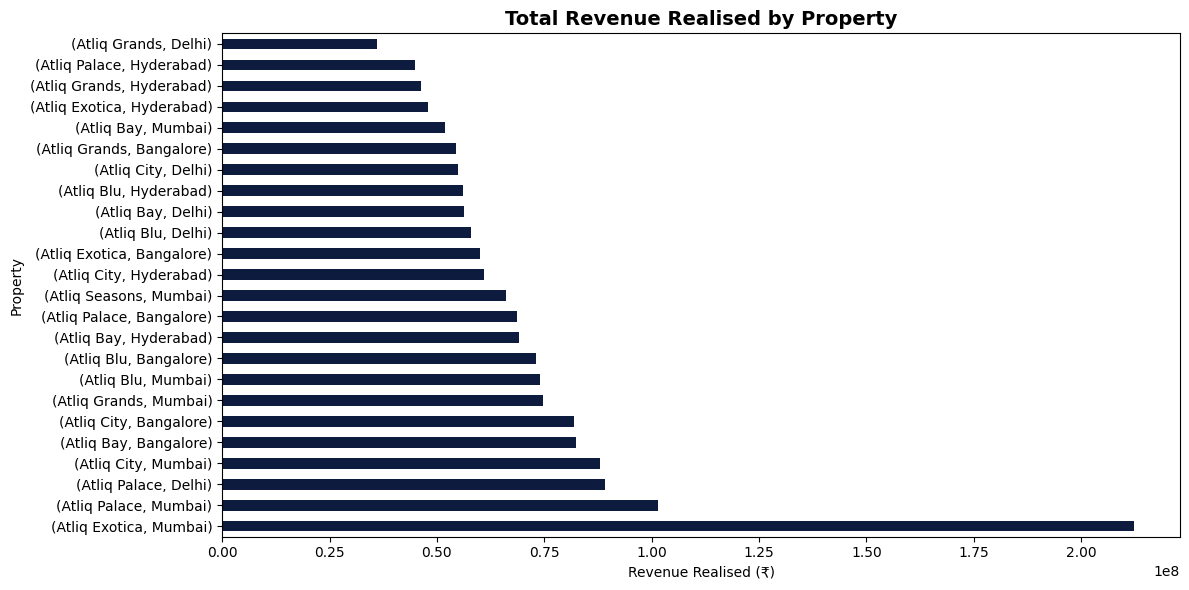

In [102]:
# =============================================================================
# INSIGHT 5 — Revenue Realised by Property
# =============================================================================

# Total revenue per property
rev_by_property = df_rev_city.groupby(
    ['property_name', 'city']
)['revenue_realized'].sum().round(2).sort_values(ascending=False)

print("Total Revenue Realised by Property:")
print(rev_by_property)

# Plot
plt.figure(figsize=(12, 6))
rev_by_property.plot(kind='barh', color='#0D1B3E')
plt.title('Total Revenue Realised by Property', fontsize=14, fontweight='bold')
plt.xlabel('Revenue Realised (₹)')
plt.ylabel('Property')
plt.tight_layout()
plt.savefig('visuals/total_revenue_Realized_by_property.png', dpi=150, bbox_inches='tight')
plt.show()


#### 🔍 Observation — Insight 5

**Top 5 Properties:**
| Property | City | Revenue |
|---|---|---|
| Atliq Exotica | Mumbai | ₹212,412,008 |
| Atliq Palace | Mumbai | ₹101,511,080 |
| Atliq Palace | Delhi | ₹89,135,998 |
| Atliq City | Mumbai | ₹87,996,216 |
| Atliq Bay | Bangalore | ₹82,443,540 |

**Bottom 3 Properties:**
| Property | City | Revenue |
|---|---|---|
| Atliq Grands | Delhi | ₹35,990,542 |
| Atliq Grands | Hyderabad | ₹46,246,510 |
| Atliq Palace | Hyderabad | ₹44,838,780 |

**Three Critical Findings:**

**1. Atliq Exotica Mumbai dominates**
At ₹212M it generates nearly **double** the second
highest property. It is single handedly carrying
Mumbai's revenue leadership from Insight 4.

**2. Same brand, dramatically different performance**
Atliq Exotica earns ₹212M in Mumbai but only
₹47M in Hyderabad — a **4x gap** for the same
brand name. This points to location, pricing
or management differences between cities.

**3. Atliq Grands is the weakest brand**
Atliq Grands appears at the bottom in both
Delhi and Hyderabad — consistent underperformance
across multiple cities signals a **brand level
problem**, not just a location problem.

**Recommendation:**
- Study what Atliq Exotica Mumbai does differently
  and replicate across other properties
- Conduct urgent review of Atliq Grands brand
  positioning — consistent bottom performance
  across cities cannot be ignored
- Consider rebranding or repositioning
  underperforming Atliq Grands properties

### 📊 Insight 6 — Month by Month Revenue Trend

**Business Question:**
How does revenue trend across the months
in our dataset — May to August 2022?

**Why this matters:**
A declining revenue trend month over month is
an early warning signal. It tells management
whether the business is recovering, stable,
or continuing to deteriorate against competitors.

Total Revenue Realised by Month:
mmm yy
May 22    581767396
Jun 22    553925855
Jul 22    572843348
Name: revenue_realized, dtype: int64


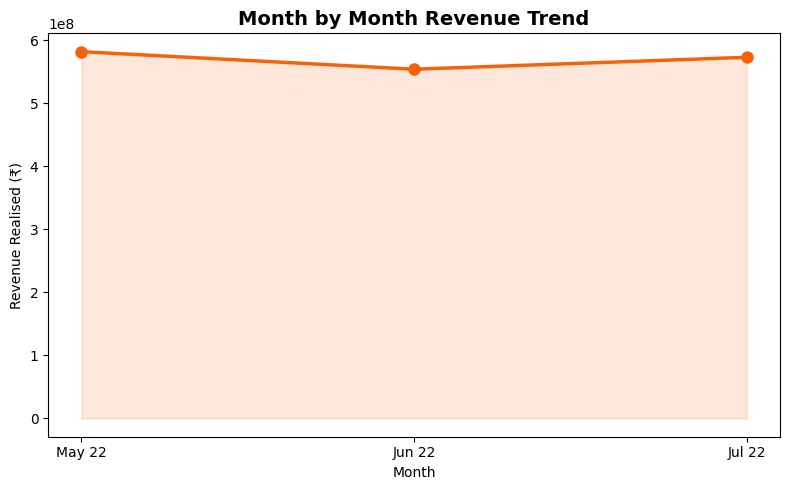

In [103]:
# =============================================================================
# INSIGHT 6 — Month by Month Revenue Trend
# =============================================================================

# Merge bookings with date table
df_rev_month = pd.merge(
    df_bookings, df_date,
    left_on='check_in_date', right_on='date'
)

# Total revenue per month
rev_by_month = df_rev_month.groupby('mmm yy')['revenue_realized'].sum()

# Reorder months chronologically
month_order = ['May 22', 'Jun 22', 'Jul 22']
rev_by_month = rev_by_month.reindex(month_order)

print("Total Revenue Realised by Month:")
print(rev_by_month)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(rev_by_month.index, rev_by_month.values,
         color='#F4630A', marker='o', linewidth=2.5, markersize=8)
plt.fill_between(rev_by_month.index, rev_by_month.values,
                 alpha=0.15, color='#F4630A')
plt.title('Month by Month Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue Realised (₹)')
plt.tight_layout()
plt.savefig('visuals/month_by_month_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


#### 🔍 Observation — Insight 6

**Results:**
| Month | Revenue Realised |
|---|---|
| May 22 | ₹581,767,396 |
| Jun 22 | ₹553,925,855 |
| Jul 22 | ₹572,843,348 |

**Business Implication:**

Revenue dipped in June then partially recovered
in July — but never returned to May levels.

Three important observations:

**1. No growth trend**
Revenue is essentially flat across three months
with a mid-period dip. For a business trying to
recover market share, flat is not good enough —
the group needs an **upward trend, not stability.**

**2. June is the weakest month**
June dropped ₹27M below May. This could be
seasonal — understanding whether this is an
industry-wide pattern or specific to Patel
Delivers requires competitor benchmarking.

**3. July recovery is incomplete**
July recovered ₹19M from June's dip but still
sits ₹9M below May — suggesting the business
has not found a way to consistently grow
month over month.

**Recommendation:**
- Investigate what drove the June dip —
  was it seasonal, competitive, or operational?
- Set a monthly revenue growth target of
  at least 3–5% month over month
- Use weekday corporate packages introduced
  in Insight 3 recommendation to drive
  consistent baseline revenue growth

### 📊 Insight 7 — Booking Platform Performance

**Business Question:**
Which booking platform drives the most revenue
and which platform has the highest cancellation rate?

**Why this matters:**
Not all booking platforms are equal. Some drive
high volume but also high cancellations — meaning
the hotel invests in serving bookings that never
materialise. Understanding platform performance
helps management decide where to invest in
partnerships and where to pull back.

Total Revenue Realised by Booking Platform:
booking_platform
others            699306762
makeyourtrip      340814104
logtrip           187494028
direct online     168948637
tripster          123066801
journey           102531334
direct offline     86374933
Name: revenue_realized, dtype: int64

Cancellation Rate by Booking Platform:
                  total_bookings  cancelled_bookings  cancellation_rate
booking_platform                                                       
direct online              13374                3343              25.00
tripster                    9630                2407              24.99
makeyourtrip               26896                6721              24.99
others                     55061               13696              24.87
journey                     8106                2009              24.78
direct offline              6753                1654              24.49
logtrip                    14753                3586              24.31


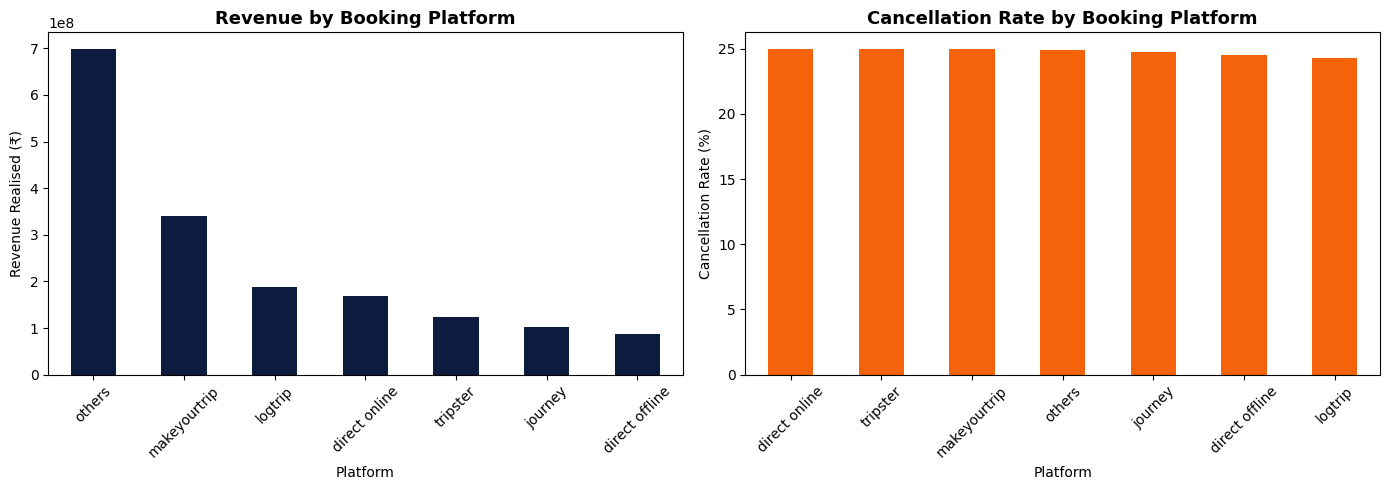

In [104]:
# =============================================================================
# INSIGHT 7 — Booking Platform Performance
# =============================================================================

# Revenue by booking platform
rev_by_platform = df_bookings.groupby(
    'booking_platform')['revenue_realized'].sum().sort_values(ascending=False)

print("Total Revenue Realised by Booking Platform:")
print(rev_by_platform)
print()

# Cancellation rate by booking platform
total_by_platform = df_bookings.groupby(
    'booking_platform')['booking_id'].count()

cancelled_by_platform = df_bookings[
    df_bookings['booking_status'] == 'Cancelled'
].groupby('booking_platform')['booking_id'].count()

df_platform = pd.DataFrame({
    'total_bookings'    : total_by_platform,
    'cancelled_bookings': cancelled_by_platform
}).fillna(0)

df_platform['cancellation_rate'] = (
    df_platform['cancelled_bookings'] /
    df_platform['total_bookings'] * 100
).round(2)

print("Cancellation Rate by Booking Platform:")
print(df_platform[['total_bookings',
                    'cancelled_bookings',
                    'cancellation_rate']].sort_values(
                    'cancellation_rate', ascending=False))

# Plot — side by side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Revenue by platform
rev_by_platform.plot(kind='bar', ax=axes[0], color='#0D1B3E')
axes[0].set_title('Revenue by Booking Platform',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Revenue Realised (₹)')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2 — Cancellation rate by platform
df_platform['cancellation_rate'].sort_values(
    ascending=False).plot(kind='bar', ax=axes[1], color='#F4630A')
axes[1].set_title('Cancellation Rate by Booking Platform',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('visuals/booking_performance.png', dpi=150, bbox_inches='tight')
plt.show()


#### 🔍 Observation — Insight 7

**Revenue by Platform:**
| Platform | Revenue |
|---|---|
| Others | ₹699,306,762 |
| MakeYourTrip | ₹340,814,104 |
| LogTrip | ₹187,494,028 |
| Direct Online | ₹168,948,637 |
| Tripster | ₹123,066,801 |
| Journey | ₹102,531,334 |
| Direct Offline | ₹86,374,933 |

**Cancellation Rate by Platform:**
| Platform | Cancellation Rate |
|---|---|
| Direct Online | 25.00% |
| Tripster | 24.99% |
| MakeYourTrip | 24.99% |
| Others | 24.87% |
| Journey | 24.78% |
| Direct Offline | 24.49% |
| LogTrip | 24.31% |

**Three Critical Findings:**

**1. "Others" is the largest revenue driver**
At ₹699M, the "Others" category — representing
unclassified booking sources — generates more
revenue than MakeYourTrip and LogTrip combined.
This is a **data quality red flag** — the hotel
group does not know where a third of its revenue
is coming from. This must be investigated and
properly classified.

**2. Cancellation rates are identical across platforms**
Every platform sits between 24.31% and 25.00% —
a difference of less than 1 percentage point.
This confirms what we found in the property level
analysis — cancellations are a **systemic business
problem**, not a platform specific one.

**3. Direct channels are underutilised**
Direct Online (₹168M) and Direct Offline (₹86M)
combined generate only ₹255M — far less than
third party platforms. Direct bookings are more
profitable because there are no commission fees
paid to third parties.

**Recommendation:**
- **Immediately audit "Others" category** — classify
  all unidentified booking sources properly
- Launch a **direct booking incentive programme** —
  loyalty points, free breakfast, or room upgrades
  for guests who book directly on the website
- Since cancellation rates are platform independent,
  focus cancellation reduction efforts on
  **booking policy changes** — stricter cancellation
  windows or non-refundable rate options

### 📊 Insight 8 — Customer Ratings by City

**Business Question:**
Which cities and properties receive the best
and worst customer ratings?

**Why this matters:**
Revenue and occupancy tell us the financial story.
Customer ratings tell us the **experience story.**
A property can be full and profitable today but
if ratings are consistently low, it will lose
customers to competitors tomorrow.
In the hotel industry, ratings directly influence
booking decisions — especially on third party
platforms like

Average Customer Rating by City:
city
Delhi       3.78
Hyderabad   3.66
Mumbai      3.65
Bangalore   3.41
Name: ratings_given, dtype: float64

Average Customer Rating by Property:
property_name  city     
Atliq Exotica  Mumbai      4.32
Atliq Bay      Hyderabad   4.30
Atliq Blu      Mumbai      4.30
Atliq Palace   Mumbai      4.29
Atliq Blu      Delhi       4.28
Atliq City     Bangalore   4.28
Atliq Bay      Bangalore   4.28
Atliq Palace   Delhi       4.27
Atliq City     Hyderabad   4.26
Atliq Grands   Delhi       4.25
Atliq Blu      Hyderabad   4.25
               Bangalore   3.08
Atliq Grands   Hyderabad   3.07
Atliq Bay      Delhi       3.07
Atliq Palace   Hyderabad   3.07
Atliq Exotica  Bangalore   3.05
Atliq Grands   Mumbai      3.05
Atliq City     Mumbai      3.04
Atliq Palace   Bangalore   3.02
Atliq City     Delhi       3.01
Atliq Bay      Mumbai      2.36
Atliq Grands   Bangalore   2.36
Atliq Exotica  Hyderabad   2.33
Atliq Seasons  Mumbai      2.30
Name: ratings_given, dtype:

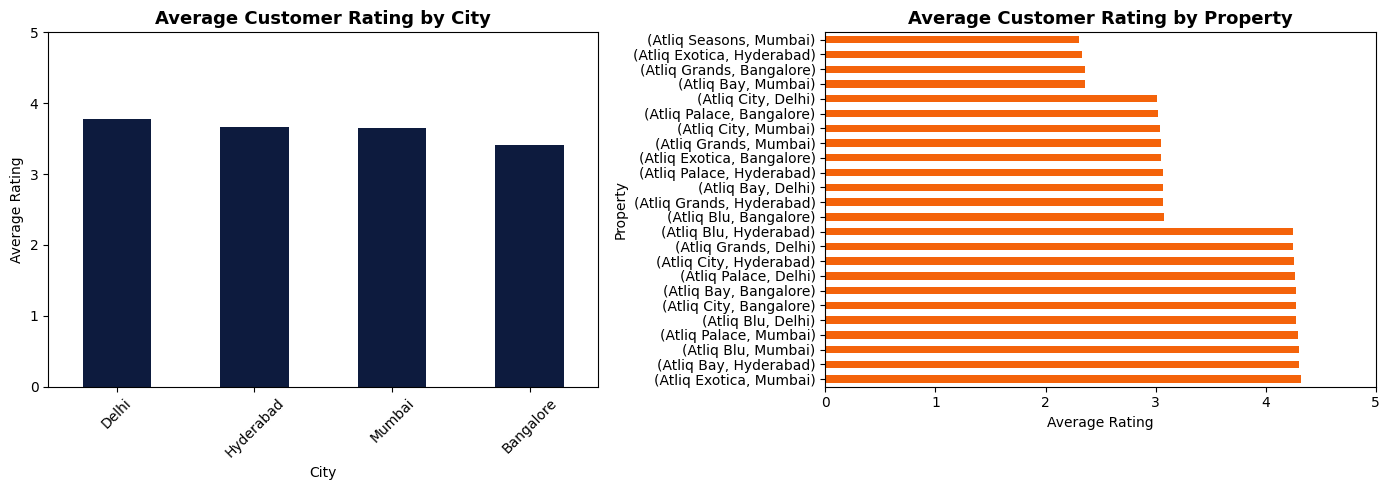

In [105]:
# =============================================================================
# INSIGHT 8 — Customer Ratings by City and Property
# =============================================================================

# Average rating by city — exclude null ratings
ratings_by_city = df_rev_city.groupby(
    'city')['ratings_given'].mean().round(2).sort_values(ascending=False)

print("Average Customer Rating by City:")
print(ratings_by_city)
print()

# Average rating by property
ratings_by_property = df_rev_city.groupby(
    ['property_name','city'])['ratings_given'].mean().round(2).sort_values(ascending=False)

print("Average Customer Rating by Property:")
print(ratings_by_property)

# Plot — side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Ratings by city
ratings_by_city.plot(kind='bar', ax=axes[0], color='#0D1B3E')
axes[0].set_title('Average Customer Rating by City',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(0, 5)
axes[0].tick_params(axis='x', rotation=45)

# Chart 2 — Ratings by property
ratings_by_property.plot(kind='barh', ax=axes[1], color='#F4630A')
axes[1].set_title('Average Customer Rating by Property',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Property')
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.savefig('visuals/occupancy_by_city.png', dpi=150, bbox_inches='tight')
plt.show()


#### 🔍 Observation — Insight 8

**Average Rating by City:**
| City | Rating |
|---|---|
| Delhi | 3.78 |
| Hyderabad | 3.66 |
| Mumbai | 3.65 |
| Bangalore | 3.41 |

**The Most Striking Finding in the Entire Analysis:**

Property ratings reveal a dramatic **two-tier split:**

**High Performers (4.25 — 4.32):**
| Property | City | Rating |
|---|---|---|
| Atliq Exotica | Mumbai | 4.32 |
| Atliq Bay | Hyderabad | 4.30 |
| Atliq Blu | Mumbai | 4.30 |
| Atliq Palace | Mumbai | 4.29 |

**Low Performers (2.30 — 3.08):**
| Property | City | Rating |
|---|---|---|
| Atliq Seasons | Mumbai | 2.30 |
| Atliq Exotica | Hyderabad | 2.33 |
| Atliq Grands | Bangalore | 2.36 |
| Atliq Bay | Mumbai | 2.36 |

**Three Critical Findings:**

**1. A 2-point rating gap within the same brand**
Atliq Exotica scores 4.32 in Mumbai but only
2.33 in Hyderabad — nearly **2 full points lower**
for the same brand name. Guests expect consistency
across locations. This level of inconsistency
actively damages brand reputation.

**2. Atliq Seasons is the most urgent problem**
At 2.30 — the lowest rating in the entire portfolio
— Atliq Seasons Mumbai is a reputational liability.
On platforms like MakeYourTrip, ratings below 3.0
significantly reduce booking conversion rates.

**3. Bangalore consistently underperforms**
Bangalore had the lowest occupancy in Insight 2,
the weakest revenue contribution, and now the
lowest average rating at 3.41. This city requires
an **urgent operational review** — the data
consistently points to a systemic problem there.

**Recommendation:**
- **Immediate action on Atliq Seasons Mumbai**
  — conduct guest feedback audit to identify
  root cause of 2.30 rating
- **Study what Atliq Exotica Mumbai does differently**
  — replicate service standards across all properties
- **Bangalore city review** — this city has now
  appeared as underperformer across occupancy,
  revenue AND ratings — escalate to senior management
- Implement a **minimum rating standard of 3.5**
  across all properties with quarterly reviews

## 🎯 Section 5 — Key Findings & Recommendations

This section summarises the most critical findings
from all 8 insights and translates them into
**actionable business recommendations.**

This is the section management acts on.

---

> *"Data analysis is not about producing charts.
> It is about telling a business what to do next
> — and why."*

### 📋 Key Findings Summary

After analysing 134,590 bookings across 25 properties
in 4 cities from May to August 2022, we identified
**5 critical business problems:**

---

**🔴 Problem 1 — Critically Low Weekday Occupancy**
Weekday occupancy sits at 51.81% versus 73.96%
on weekends — a 22 percentage point gap indicating
the hotel group is almost entirely dependent on
leisure travellers and has failed to capture
the highly profitable corporate travel segment.

**Action:** Launch weekday corporate packages and
dynamic pricing immediately across Delhi,
Mumbai and Hyderabad.

---

**🔴 Problem 2 — Delhi Revenue Paradox**
Delhi has the highest occupancy at 61.51% but
generates the least revenue at ₹294M. Rooms are
being sold too cheaply — the group is leaving
significant money on the table in its strongest
occupancy market.

**Action:** Conduct immediate room rate review
in Delhi — occupancy is strong enough to
support 15–20% price increases.

---

**🔴 Problem 3 — Atliq Grands Brand Underperformance**
Atliq Grands consistently appears at the bottom
of both revenue and ratings across multiple cities.
This is not a location problem — it is a
brand positioning problem.

**Action:** Commission a full brand review of
Atliq Grands — consider repositioning,
rebranding or operational restructuring.

---

**🔴 Problem 4 — Direct Booking Channel Underutilised**
Third party platforms dominate revenue while
direct online and offline channels generate
only ₹255M combined. Every third party booking
incurs commission costs that erode profit margins.

**Action:** Introduce a direct booking loyalty
programme with tangible guest incentives —
free upgrades, breakfast inclusion or
loyalty points.

---

**🔴 Problem 5 — Bangalore Systemic Failure**
Bangalore ranked last in occupancy, revenue
and customer ratings consistently across
all 8 insights. This is not coincidence —
it is a systemic operational failure
requiring urgent senior management attention.

**Action:** Conduct a full operational audit
of all Bangalore properties — review staffing,
pricing, marketing and competitive positioning
in that market.

---

### 💡 If Only One Action is Taken

> Fix weekday occupancy through corporate
> packages and dynamic pricing. A 10 percentage
> point improvement in weekday occupancy across
> all properties would generate an estimated
> **₹150–200M in additional annual revenue.**